<a href="https://colab.research.google.com/github/diepxr/Predictivos-del-precio-del-caf-ar-bica-en-Colombia/blob/main/proyecto_machine_learning_2026_1_diego_parra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN CIENCIA DE DATOS**

ESCUELA COLOMBIANA DE INGENIERÍA "JULIO GARAVITO“

MLEA_M: Machine Learning

Presentación final de curso

**Diego Parra**

**Modelo de Regresión Multivariada para la Predicción de Futuros de Café Arábico; basado en reportes de existencias de ICE  y el clima de brasil.**


**Problema y motivación:**


El café arábico se cotiza en diferentes bolsas o mercados organizados en los cuales se compran y venden commodities. Estos mercados ***fijan los precios mundiales del grano mediante un ejercicio de oferta y demanda***, sirviendo como referencia global para su comercialización; este valor impacta a intermediarios, consumidores y caficultores en todo el mundo.

Las fluctuaciones de precio responden a múltiples factores que afectan dicha oferta o demanda. Entre ellos destaca el volumen de existencias medido por el ***ICE (Intercontinental Exchange)***, uno de los operadores de bolsa más grandes del mundo. El ICE genera el ***Certified Warehouse Stock Report***, un informe que indica la cantidad de café (en sacos de 60 kg) almacenada en bodegas especializadas y aprobadas por la entidad. Este reporte funciona como un indicador de la oferta —sin ser un dato exacto de la existencia total de café a nivel mundial— y se toma como referencia clave: ante caídas drásticas de los inventarios, el precio tiende al alza.

Otro factor determinante en la oferta y los precios es el ***clima en Brasil, el mayor productor de café arábico del mundo***. Dado que el cultivo no se distribuye en todo el país, sino que se concentra principalmente en el estado de ***Minas Gerais (región sureste)***, es fundamental analizar los datos meteorológicos de esa zona de interés. Para ello, se utilizan los registros del INMET (Instituto Nacional de Meteorología de Brasil), organismo oficial que provee dicha información.

Para los caficultores, intermediarios y comercializadoras, es vital gestionar el riesgo financiero derivado de su actividad económica. Por esta razón, contar con una guía que estime las fluctuaciones del precio en la bolsa, en relación con las variables que históricamente lo han afectado, resulta de gran valor. ***El presente ejercicio se plantea como un problema de regresión multivariada, cuyo objetivo es servir de apoyo en la toma de decisiones estratégicas para la compra y venta de café arábico.***

**Fuentes de los datos:**

- **Precios históricos**: Los precios del café arábica se toman de **Investing.com**, un portal de información financiera ampliamente utilizado por analistas de mercados bursátiles a nivel mundial.

- **Inventarios**: El reporte de existencias **(Certified Warehouse Stock Report)** se obtiene de **ICE (Intercontinental Exchange)**, uno de los operadores de bolsa más grandes del mundo.

- **Clima en Brasil**: Los datos provienen del ***INMET (Instituto Nacional de Meteorología de Brasil)***.

Las tres son plataformas públicas con acceso libre a la información. Los datos se analizarán en el horizonte de tiempo comprendido entre el ***1 de enero de 2022 y el 31 de diciembre de 2025***. El número de observaciones dependerá del análisis, puesto que la información de precios varía por minuto, hora, día o mes (según el cierre de mercados). No obstante, los datos de existencias tienen una frecuencia diaria y las precipitaciones en Minas Gerais se registran por hora.

**Entre las variables mas relevantes del problema tenemos:**

- **Precio**: Se toma como referencia el precio al cierre del ejercicio financiero por día.

- **Existencias de café**: La cantidad de sacos almacenados es un indicador de la oferta; la escasez suele incrementar el precio. Cabe aclarar que esto no refleja la disponibilidad mundial total.

- **Variables rezagadas (Lags)**: Se considera que los efectos del clima o de los informes de existencias no tienen un impacto inmediato en el precio; una vez se conoce la noticia, el efecto puede tardar horas o días en reflejarse.

- **Pronóstico climático**: Al contar con el pronóstico de Minas Gerais, el modelo tendrá una ventaja predictiva importante.

**Problemas con los datos:**

-	Los datos de bolsa solo registran **valores entre semana**, mientras que los fines de semana y festivos son datos faltantes.

-	Por el contrario, el **clima registra precipitaciones todos los días** y a toda hora.

-	Se debe revisar la **alineación de los datos de clima** de todos los días y todas horas con los precios que se toma solo entre semana, sin festivos y por día y no horas.  

-	Las bases de datos de clima tiene **espacios en blanco**.

-	Estandarización o **normalización** de los datos, como los inventarios están en millones de sacos y los datos del clima están en milímetros las escalas afectan el modelo. (técnica de **escalado de datos** a aplicar StandardScaler)

-	A partir de dataset **coffee_cert_stock_20230717 cambio el formato** entonces hay que darle otro tratamiento a los datos.

- En la validación de código, se detecto que en los archivos de existencia, algunos tenían **error en los nombres, Ejemplo el archivo 20230225**, estaba 202302025, Se detecto estos errores y se ajusto el nombre manualmente ya que de los 1001 archivos solo había error en 10.

**Decisiones importantes:**

- Los días como **fines de semana,** donde los precios no tiene información se define **excluir los días** y no rellenarlos para no integrar al modelo datos artificiales que puedan ingerir en un error al modelo y que no aprenda que hay días que el precio no se mueve a pesar de que el clima si lo haga.
- El clima que vivimos hoy, como no tiene un efecto inmediato en al precio, el Lags de la variable rezagada tiene la siguiente afirmación: ***"El clima de hoy afecta el precio de mañana"***
- Los datos que puedan llegar a tener el **precio**, pero **sin dato de existencia**; se rellena con datos de existencia del día inmediatamente anterior.




Todos los archivos están almacenados en carpeta de drive, A continuación, se carga el histórico de precios del café arábica en el horizonte de tiempo objeto de estudio.

In [ ]:
import pandas as pd
from google.colab import drive
import csv
import numpy as np
import os
import glob
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, max_error, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/MLEA_M: Machine Learning 2026_1/Precios_NY/Datos históricos Café C EE.UU. (Dia).csv'

df = pd.read_csv(file_path, delimiter=',',decimal=',')
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y')
df['Último'] = pd.to_numeric(df['Último'])
df = df.sort_values(by='Fecha').reset_index(drop=True)
data = df[['Fecha', 'Último']].copy()

data.set_index('Fecha', inplace=True)
dataset = data['Último'].values.reshape(-1, 1)
print("Random sample of the loaded DataFrame:")
display(df.sample(3))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Random sample of the loaded DataFrame:


,Fecha,Último,Apertura,Máximo,Mínimo,Vol.,% var.
752,2024-12-31,319.75,318.85,321.30,312.15,"14,69K","-0,39%"
712,2024-11-01,242.95,246.30,249.25,241.30,"23,12K","-1,20%"
933,2025-09-22,367.35,369.20,370.15,360.55,"12,99K","0,23%"


A continuación, se cargan todos los archivos de información de precipitaciones de Minas Gerais de Brasil, se consolida todas las bases de datos ya que es un archivo por ciudad y por año. Los datos se suman en el día y se promedia por ciudad:

In [ ]:


# 1. carpeta de Clima en tu Drive
folder_path_clima = '/content/drive/MyDrive/MLEA_M: Machine Learning 2026_1/Clima_Brasil'

# 2. Buscar todos los archivos CSV dentro de la carpeta
archivos_clima = glob.glob(os.path.join(folder_path_clima, '*.CSV'))

lista_clima = []

# 3. Iterar sobre cada archivo de municipio/año
for archivo in archivos_clima:
    try:

        df_temp = pd.read_csv(archivo, sep=';', skiprows=8, encoding='latin-1', decimal=',')


        df_temp.columns = df_temp.columns.str.strip()


        col_fecha = 'Data'

        col_precip = [col for col in df_temp.columns if 'PRECIPITA' in col.upper()][0]


        df_temp = df_temp[[col_fecha, col_precip]].copy()
        df_temp.rename(columns={col_precip: 'Precipitacion_mm'}, inplace=True)


        df_temp['Precipitacion_mm'] = pd.to_numeric(df_temp['Precipitacion_mm'], errors='coerce').fillna(0)


        df_temp['Fecha'] = pd.to_datetime(df_temp[col_fecha])


        df_diario_municipio = df_temp.groupby('Fecha')['Precipitacion_mm'].sum().reset_index()

        lista_clima.append(df_diario_municipio)

    except Exception as e:
        print(f"Error procesando el archivo {os.path.basename(archivo)}: {e}")

# 4. Consolidar todos los municipios en un solo DataFrame
df_clima_total = pd.concat(lista_clima, ignore_index=True)

# 5. Agrupar por fecha para PROMEDIAR la lluvia en todo Minas Gerais ese día
df_clima_final = df_clima_total.groupby('Fecha')['Precipitacion_mm'].mean().reset_index()

# Ordenar cronológicamente
df_clima_final = df_clima_final.sort_values(by='Fecha').reset_index(drop=True)

print("Muestra aleatoria del clima consolidado diario en Minas Gerais:")
display(df_clima_final.sample(3))




Muestra aleatoria del clima consolidado diario en Minas Gerais:


,Fecha,Precipitacion_mm
596,2023-08-20,3.96875
692,2023-11-24,5.65625
599,2023-08-23,0.01250


A continuación, se cargan todos los archivos de información de Certified Warehouse Stock Report, la manera de procesar esta información es buscar y extraer de cada archivo la última columna de la fila llamada "Total in Bags", y la fecha se extrae del nombre de cada archivo y se convierte en el formato fecha:

In [ ]:
!pip install xlrd

In [ ]:
# 1. Carpeta de Existencias
folder_path_inventarios = '/content/drive/MyDrive/MLEA_M: Machine Learning 2026_1/Existencias'

# 2. Buscar todos los archivos Excel en la carpeta
archivos_inv = glob.glob(os.path.join(folder_path_inventarios, 'coffee_cert_stock_*.xls'))

# Contador para verificar que sí encontró la carpeta y los archivos
print(f"¡Se encontraron {len(archivos_inv)} archivos de inventarios!")

datos_inv = []

# 3. Iterar sobre cada archivo
for archivo in archivos_inv:
    try:

        nombre_base = os.path.basename(archivo)
        fecha_str = nombre_base.split('_')[3].replace('.xls', '')
        fecha = pd.to_datetime(fecha_str, format='%Y%m%d') # Convierte '20220103' a formato fecha


        df = pd.read_excel(archivo)


        fila_total = df[df.apply(lambda row: row.astype(str).str.contains('Total in Bags', case=False, na=False).any(), axis=1)]

        if not fila_total.empty:

            valores_fila = fila_total.iloc[0].dropna().values


            total_sacos = valores_fila[-1]

            datos_inv.append({'Fecha': fecha, 'Inventario_Sacos': total_sacos})
        else:
            print(f"No se encontró la frase 'Total in Bags' en el archivo {nombre_base}")

    except Exception as e:
        print(f"Error procesando el archivo {os.path.basename(archivo)}: {e}")


df_inventarios = pd.DataFrame(datos_inv)


if not df_inventarios.empty:
    df_inventarios = df_inventarios.sort_values(by='Fecha').reset_index(drop=True)
    print("\n Procesamiento terminado. Muestra aleatoria del consolidado de inventarios:")
    display(df_inventarios.sample(5))
else:
    print("\n No se pudieron extraer datos.")

¡Se encontraron 1001 archivos de inventarios!

 Procesamiento terminado. Muestra aleatoria del consolidado de inventarios:


,Fecha,Inventario_Sacos
561,2024-04-02,604079
8,2022-01-13,1412316
666,2024-08-30,847873
541,2024-03-02,371107
969,2025-11-14,403190


**Alineación de criterios y unión:**

Los precios es nuestra variable mandataria y la fecha es nuestra llave de unión entonces se utilizarán los días hábiles de bolsa de valores para hacer la unión de las tres variables.


In [ ]:
# 1. UNIR TODO (MERGE)

df_final = pd.merge(data, df_inventarios, on='Fecha', how='left')
df_final = pd.merge(df_final, df_clima_final, on='Fecha', how='left')


df_final = df_final.sort_values('Fecha').reset_index(drop=True)

# 2. TRATAMIENTO DE DATOS FALTANTES (IMPUTACIÓN)

# Inventarios: Si un día de bolsa no hay reporte

df_final['Inventario_Sacos'] = df_final['Inventario_Sacos'].ffill()

# Clima: Si falta el dato de lluvia en un día de bolsa,asumimos que no hubo precipitación (0 mm).

df_final['Precipitacion_mm'] = df_final['Precipitacion_mm'].fillna(0)

# 3. LIMPIEZA FINAL

df_final = df_final.dropna()


print("Fusión completada con éxito.")
print(f"Tamaño final del dataset: {df_final.shape[0]} días de mercado.")
print("\nConteo de valores nulos por columna:")
print(df_final.isnull().sum())

display(df_final.head())

Fusión completada con éxito.
Tamaño final del dataset: 1004 días de mercado.

Conteo de valores nulos por columna:
Fecha               0
Último              0
Inventario_Sacos    0
Precipitacion_mm    0
dtype: int64


,Fecha,Último,Inventario_Sacos,Precipitacion_mm
0,2022-01-03,223.30,1538204.0,10.53125
1,2022-01-04,231.75,1535247.0,8.51250
2,2022-01-05,231.75,1531803.0,10.07500
3,2022-01-06,231.70,1516417.0,16.90625
4,2022-01-07,238.45,1506480.0,26.13750


**Limpieza de la data:**

Se realiza limpieza de los datos conforme a:

- Ajuste de datos faltantes de existencias
- Creación de las variables rezagadas, "El clima de hoy afecta el precio de mañana". Lo mismo aplica para las existencias.
- Definición de las variables dependiente e independientes
- Estandarización por escalas de los datos:

se utiliza StandardScaler Z-score donde  $$z = \frac{x - \mu}{\sigma}$$

Funcionamiento: Calcula el promedio histórico de cada variable y convierte ese promedio en 0, después toma cada dato y estima su proporción correspondiente respecto al 0.O los normaliza. Esto se realiza para que los datos con números muy grandes como las existencias no les reste importancia a datos como el clima que puede ser números muy pequeños.



In [ ]:



# --- 1. AJUSTE DE DATOS FALTANTES (EXISTENCIAS) ---

df_final = df_final.sort_values('Fecha').reset_index(drop=True)

df_final['Inventario_Sacos'] = df_final['Inventario_Sacos'].ffill()

# --- 2. CREACIÓN DE VARIABLES REZAGADAS (LAGS) ---

df_final['Lluvia_Ayer'] = df_final['Precipitacion_mm'].shift(1)
df_final['Inventario_Ayer'] = df_final['Inventario_Sacos'].shift(1)
df_final['Precio_Ayer'] = df_final['Último'].shift(1)

# --- 3. LIMPIEZA POST-LAG ---

df_final = df_final.dropna().reset_index(drop=True)

# --- 4. PREPARACIÓN DE X (FEATURES) Y Y (TARGET) ---

columnas_features = ['Precio_Ayer', 'Lluvia_Ayer', 'Inventario_Ayer']
X = df_final[columnas_features]
y = df_final['Último']

# --- 5. ESTANDARIZACIÓN DE LOS DATOS ---

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_final = pd.DataFrame(X_scaled, columns=columnas_features)

print(f"Fase 3 completada {X_final.shape[0]} muestras.")
display(X_final.head())

Fase 3 completada 1003 muestras.


,Precio_Ayer,Lluvia_Ayer,Inventario_Ayer
0,-0.298290,1.797092,3.366344
1,-0.189126,1.319112,3.354351
2,-0.189126,1.689066,3.340383
3,-0.189772,3.306502,3.277980
4,-0.102570,5.492187,3.237678


**EDA:**

Descripción estadística y visualizaciones relevantes

In [ ]:
print("Estadísticas Descriptivas del Dataset (Valores Reales):")

estadisticas = df_final.describe().round(2)

display(estadisticas)

Estadísticas Descriptivas del Dataset (Valores Reales):


,Fecha,Último,Inventario_Sacos,Precipitacion_mm,Lluvia_Ayer,Inventario_Ayer,Precio_Ayer
count,1003,1003.00,1003.00,1003.00,1003.00,1003.00,1003.00
mean,2024-01-02 12:27:59.760717568,246.51,707118.23,2.94,2.94,708200.03,246.39
min,2022-01-04 00:00:00,143.90,224066.00,0.00,0.00,224066.00,143.90
25%,2023-01-03 12:00:00,185.60,515725.00,0.05,0.05,517960.00,185.60
50%,2024-01-03 00:00:00,225.70,751044.00,0.84,0.84,753981.00,225.70
75%,2025-01-01 00:00:00,302.80,846033.00,4.57,4.57,846489.00,301.77
max,2025-12-31 00:00:00,432.35,1535247.00,30.46,30.46,1538204.00,432.35
std,NaN,77.51,245414.83,4.23,4.23,246682.43,77.45


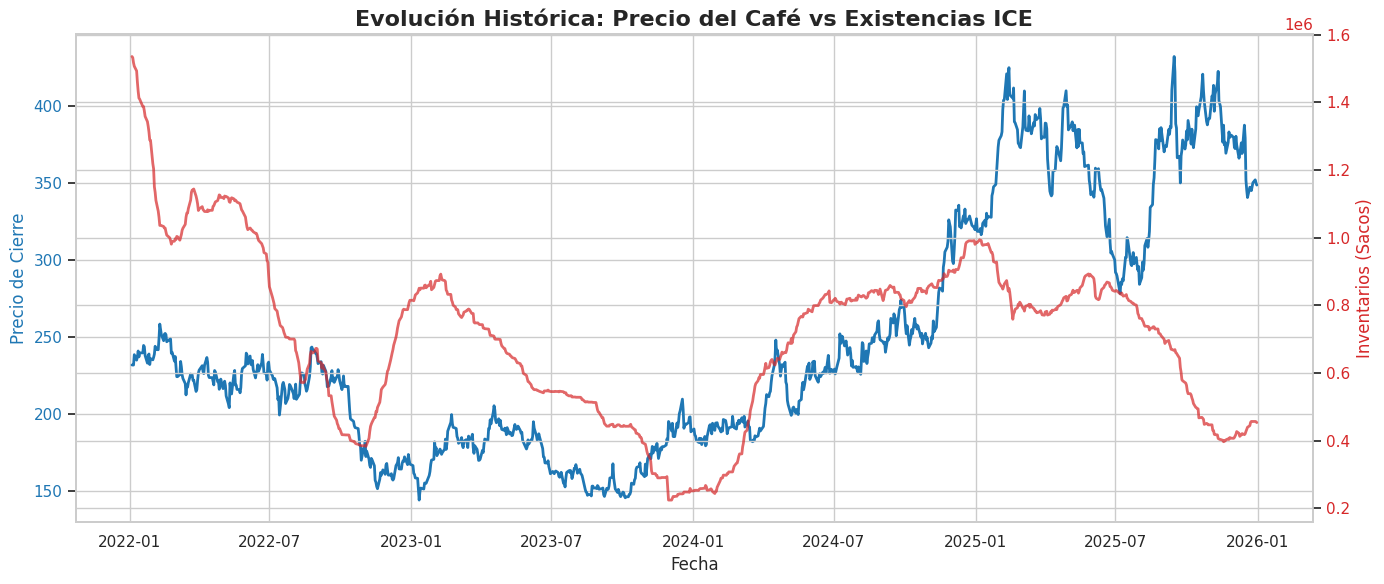

In [ ]:

sns.set_theme(style="whitegrid")

# ==============================================================================
# GRÁFICO DE LÍNEAS CON DOBLE EJE (PRECIO VS INVENTARIO)
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(14, 6))


color_precio = '#1f77b4' # Azul
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Precio de Cierre', color=color_precio, fontsize=12)
ax1.plot(df_final['Fecha'], df_final['Último'], color=color_precio, linewidth=2, label='Precio del Café')
ax1.tick_params(axis='y', labelcolor=color_precio)


ax2 = ax1.twinx()
color_inv = '#d62728'
ax2.set_ylabel('Inventarios (Sacos)', color=color_inv, fontsize=12)
ax2.plot(df_final['Fecha'], df_final['Inventario_Sacos'], color=color_inv, linewidth=2, alpha=0.7, label='Existencias ICE')
ax2.tick_params(axis='y', labelcolor=color_inv)

plt.title('Evolución Histórica: Precio del Café vs Existencias ICE', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()


Con este grafico se pueden concluir 3 argumentos:

1. En algunos tramos como lo que pasa desde inicios de 2025 a mayor escasez de existencias mayor el precio de los futuros, otro ejemplo es a inicios del 2023 a mayor inventario es menor el precio.
2. Se evidencia en algunos tramos que la información de las existencias rezaga más la respuesta del precio, no es solo de un día puede ser hasta semanas.
3. Caso 2022, al inicio del ejercicio se ve que hay grandes volúmenes de inventario y eso no parece afectar el precio, esto indica el precio tiene dependencia de otras variables.


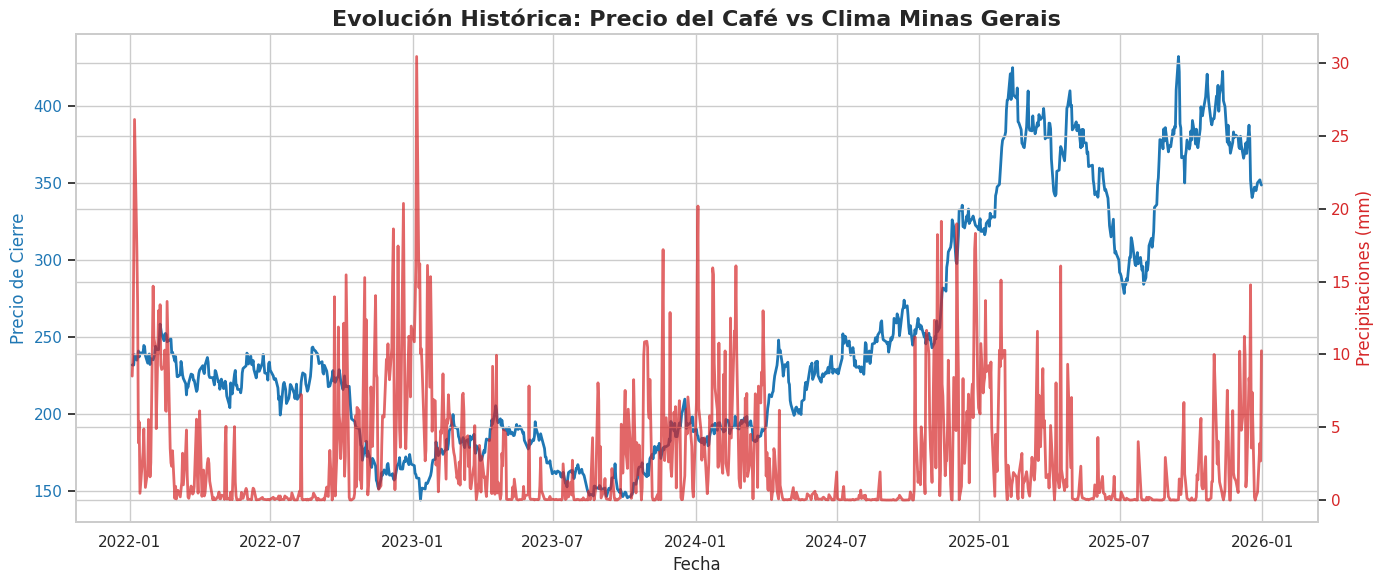

In [ ]:

# ==============================================================================
# GRÁFICO DE LÍNEAS CON DOBLE EJE (PRECIO VS PRECIPITACIONES)
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(14, 6))


color_precio = '#1f77b4'
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Precio de Cierre', color=color_precio, fontsize=12)
ax1.plot(df_final['Fecha'], df_final['Último'], color=color_precio, linewidth=2, label='Precio del Café')
ax1.tick_params(axis='y', labelcolor=color_precio)


ax2 = ax1.twinx()
color_inv = '#d62728'
ax2.set_ylabel('Precipitaciones (mm)', color=color_inv, fontsize=12)
ax2.plot(df_final['Fecha'], df_final['Precipitacion_mm'], color=color_inv, linewidth=2, alpha=0.7, label='Clima Minas Gerais')
ax2.tick_params(axis='y', labelcolor=color_inv)

plt.title('Evolución Histórica: Precio del Café vs Clima Minas Gerais', fontsize=16, fontweight='bold')
fig.tight_layout()  # Ajusta los márgenes para que no se corte nada
plt.show()


Este grafico es muy interesante en varios aspectos:

1. El periodo de abril 2024 hasta octubre 2024 fueron épocas de pocas lluvias, esto hizo que el precio estuviera en un crecimiento constante incluyendo el siguiente semestre es decir que existe un rezado de meses
2. Finalizando el 2024 y el primer trimestre de 2025, ya se presentaron lluvias intermitentes, esto ya suavizo la curva de precios
3. Enero 2023 parece haber tenido un efecto inmediato en el precio con una fuerte lluvia un precio bastante bajo


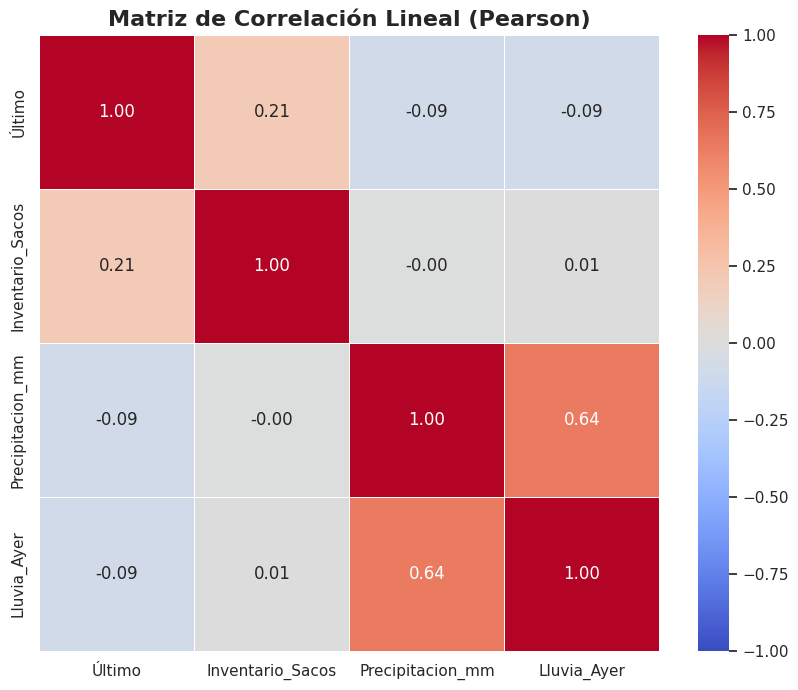

In [ ]:

# ==============================================================================
# MATRIZ DE CORRELACIÓN (HEATMAP)
# ==============================================================================
plt.figure(figsize=(10, 8))


columnas_corr = ['Último', 'Inventario_Sacos', 'Precipitacion_mm', 'Lluvia_Ayer']
matriz_correlacion = df_final[columnas_corr].corr()


sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación Lineal (Pearson)', fontsize=16, fontweight='bold')
plt.show()


La matriz de correlación no muestra una conexión fuerte entre las existencias o clima vs el precio, sin embargo, es entendible porque no es un modelo de regresión netamente lineal.

Por otro lado, una baja correlación entre las lluvias y el precio nos indica que el precio no cambia porque de un día a otro llovió 2 mm más que ayer. Los mercados reaccionan por los eventos noticioso como son las heladas o sequias. Esto lleva a concluir que el modelo debería identificar estos valores como señales de alerta, a modo de ejemplo la falta de lluvia en el periodo de marzo a octubre de 2024 crea un entorno de sequía que hace que los precios de 2025 se sigan viendo influenciados por estos sentimientos.


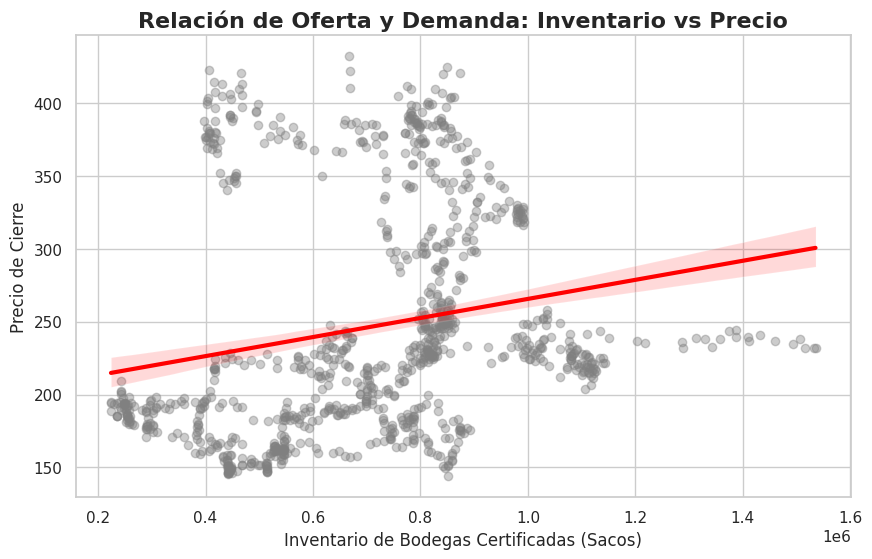

In [ ]:

# ==============================================================================
# GRÁFICO DE DISPERSIÓN (SCATTER PLOT CON TENDENCIA)
# ==============================================================================
plt.figure(figsize=(10, 6))


sns.regplot(data=df_final, x='Inventario_Sacos', y='Último',
            scatter_kws={'alpha':0.4, 'color':'gray'}, line_kws={'color':'red', 'linewidth':3})

plt.title('Relación de Oferta y Demanda: Inventario vs Precio', fontsize=16, fontweight='bold')
plt.xlabel('Inventario de Bodegas Certificadas (Sacos)', fontsize=12)
plt.ylabel('Precio de Cierre', fontsize=12)
plt.show()


A primera vista se evidencia que la línea roja crece a mayor inventario mayor precio, sin embargo, los puntos grises no tienen un comportamiento lineal y expresan otras cosas en cada acumulación de datos, por ejemplo, los puntos superiores izquierdos muestran que entre menos inventario mayor costo. No obstante, también hay grupos grandes que muestran lo contrario precios bajos en escasez esto refuerza la necesidad de implementación de modelos avanzados.

/tmp/ipykernel_9877/2934266772.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Mes', y='Precipitacion_mm', palette='YlGnBu')


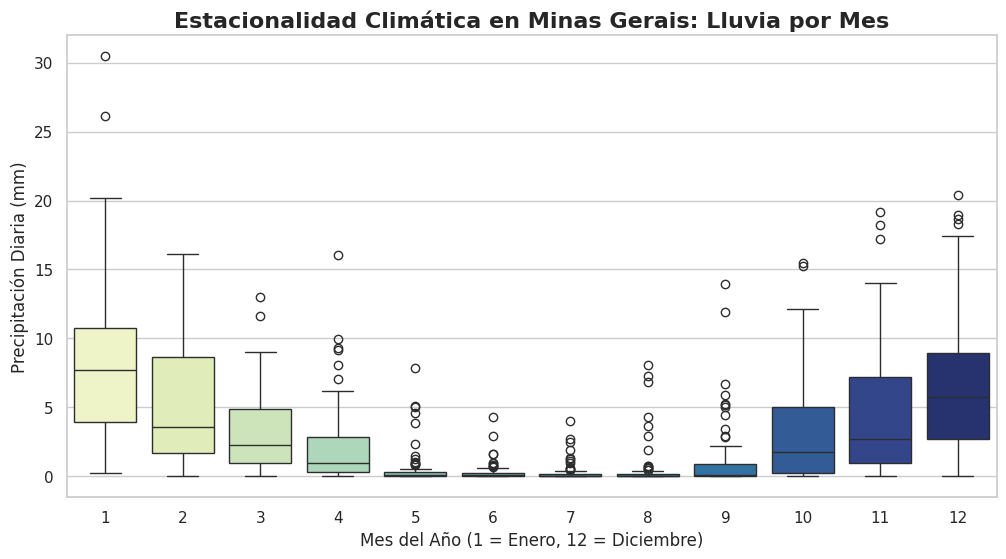

In [ ]:

# ==============================================================================
# ESTACIONALIDAD DEL CLIMA (BOXPLOT POR MES)
# ==============================================================================

df_final['Mes'] = df_final['Fecha'].dt.month

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_final, x='Mes', y='Precipitacion_mm', palette='YlGnBu')

plt.title('Estacionalidad Climática en Minas Gerais: Lluvia por Mes', fontsize=16, fontweight='bold')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)', fontsize=12)
plt.ylabel('Precipitación Diaria (mm)', fontsize=12)
plt.show()


df_final = df_final.drop(columns=['Mes'])

Este grafico de cajas y bigotes muestra que de los meses de mayo a agosto son meses de escazas lluvias y de septiembre a abril es una temporada de invierno son datos muy importantes, ya que, si el modelo detecta que en un mes de lluvias normales como enero no llueve, eso seguramente tendrá un efecto directo en el precio.

Los datos tan atípicos como lluvias promedias de 30 mm, en este ejercicio no es un outliers, si no un dato valioso para el modelo ya que aprenderá cómo reacciona el mercado con eventos extremos el cual es normal en el día a día de la bolsa.

La temporada de pocas lluvias es una temporada de gran riesgo de heladas para los cultivos, si se combina esta información con la temperatura se podría tener un detector de heladas y una variable que influencia directamente el precio.


**Modelos:**

Se escogieron los siguientes tres modelos de algoritmo avanzados para abordar el problema de regresión multivariada.



**Random Forest Regressor:**

***Como funciona:*** Toma varios subconjuntos de datos de toda la data, toma diferentes variables a analizar para esta regresión promedia cada una de las predicciones que calculo cada árbol

Ventajas:
1. Al dividirse en varios subconjuntos o arboles los niveles de ruido o outliers suelen tener menor impacto en la predicción, tal cual como se vio en el diagrama de cajas de clima para mes 1 identifico tormentas, este dato no lo excluye, pero baja su impacto contemplándolo a segmentar los árboles.
2. según el diagrama de dispersión al localizar los puntos de una forma no lineal es perfecto al analizar subconjuntos de datos

Limitaciones: La principal limitación es que solo puede trabajar con el horizonte de datos es decir que no podrá predecir un valor si existe un dato histórico de precio.




**Support Vector Regression (SVR):**

Como funciona: La idea de SVR es encontrar una línea (Hiperplano) entre las clases y que separe con los vectores de soporte las instancias de entrenamiento.

Ventajas: existen dos ventajas muy notables, la
1. Al utilizar el StandardScaler los datos funcionaran de una manera óptima para el modelo,
2. Por otro lado permite ser flexible con outliers, ya que el margen blando tiene algunas consideraciones en el modelo y esto para esta serie de datos es muy importante, porque los outliers en el clima nos va a mostrar un comportamiento en el precio crucial, y en las predicciones cuando se conozca un dato atípico como una tormenta el modelo considera y entiende este comportamiento

Limitaciones: Se debe tener mucha sensibilidad con la regularización (c), ya que considerar o no algunos datos como errores, dejarlos fuera o dentro del tuvo, puede causar sobre ajustes.



**Gradient Boosting Regressor:**

Como funciona: Inicia parecido con random forest, pero toma un subconjunto y calcula el error residual. Posterior a eso intenta predecir el error del primer árbol y así sigue de forma secuencial, al final suma las predicciones de todos árboles para tratar de acercarse al valor real.

Ventajas: Es preciso para los datos heterogéneos por ejemplo la mezcla entre clima y las existencias, además es potente para aprender la interacción entre las variables rezagadas

Limitaciones: Al ser un corrector de errores por naturaleza puede ser más propenso a sobre ajuste si entiende muchos outliers.



In [ ]:

# ==============================================================================
# 1. DIVISIÓN DE DATOS (TRAIN / TEST)
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

print(f"Datos de Entrenamiento: {X_train.shape[0]} días")
print(f"Datos de Prueba (Futuro): {X_test.shape[0]} días")

# ==============================================================================
# 2. CONFIGURACIÓN DE VALIDACIÓN CRUZADA PARA SERIES DE TIEMPO
# ==============================================================================

tscv = TimeSeriesSplit(n_splits=3)

# ==============================================================================
# 3. DEFINICIÓN DE MODELOS Y GRILLAS DE HIPERPARÁMETROS
# ==============================================================================
modelos = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}


parametros = {
    "Random Forest": {
        'n_estimators': [50, 100, 200], # Cantidad de árboles
        'max_depth': [None, 10, 20],    # Profundidad para evitar overfitting
        'min_samples_split': [2, 5]
    },
    "SVR": {
        'kernel': ['rbf', 'linear'],
        'C': [0.1, 1, 10],              # Penalización por error
        'gamma': ['scale', 'auto']      # Influencia de un solo punto
    },
    "Gradient Boosting": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2], # Tasa de aprendizaje
        'max_depth': [3, 5, 7]
    }
}

# ==============================================================================
# 4. ENTRENAMIENTO Y OPTIMIZACIÓN (GRID SEARCH) + MÉTRICAS COMPLETAS
# ==============================================================================
mejores_modelos = {}
resultados_metricas = []

print("\nIniciando optimización de hiperparámetros. Esto puede tomar unos minutos...\n")

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")


    grid_search = GridSearchCV(estimator=modelo,
                               param_grid=parametros[nombre],
                               cv=tscv,
                               scoring='neg_mean_squared_error',
                               n_jobs=-1) # Usa todos los núcleos del procesador

    grid_search.fit(X_train, y_train)


    mejor_modelo = grid_search.best_estimator_
    mejores_modelos[nombre] = mejor_modelo

    # Predecir sobre los datos de prueba (El 20% más reciente)
    y_pred = mejor_modelo.predict(X_test)


    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)


    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    max_err = max_error(y_test, y_pred)


    resultados_metricas.append({
        "Modelo": nombre,
        "Mejores Parámetros": str(grid_search.best_params_),
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "R2": round(r2, 4),
        "MAPE (%)": round(mape, 2),
        "Max Error": round(max_err, 2)
    })

Datos de Entrenamiento: 802 días
Datos de Prueba (Futuro): 201 días

Iniciando optimización de hiperparámetros. Esto puede tomar unos minutos...

Entrenando Random Forest...
Entrenando SVR...
Entrenando Gradient Boosting...


**Técnica de optimización:**

Se selecciono GridSearchCV, ya que no es un dataset con un volumen tan alto el GridSearchCV prueba todas las combinaciones posibles de los parámetros de igual manera se debe combinar con el uso de TimeSeriesSplit para que no mezcle los datos al azar y no use datos del clima de 2025 para estimar precios de 2022



**Hiperparametros:**

***1. Random Forest Regressor:***

•	n_estimators (50, 100, 200): se le dice cuántos arboles debe tomar, como no sé cuántos arboles son los ideales entonces debe probar con estos y puedes ir más allá.

•	max_depth (None, 10, 20): Es la profundidad de lo que puede crecer cada árbol como máximo para que se limite y no se sobre ajuste. None arboles infinitos, 10 árboles es corto, 20 árboles es intermedio.

•	min_samples_split (2, 5): Número mínimo por el cual se divide una rama del árbol, otro parámetro para evitar sobre ajuste.


La librería arma un modelo de 3x3x2 variables posibles que le dan los parámetros en total 18 modelos. Y estos modelos sirven para evaluar el resultado de las predicciones.

**2. Support Vector Regression (SVR):**

•	kernel ('rbf', 'linear'): toma los datos 2D y los lanza en un plano 3D así el modelo por más outliers que tenga encuentra la forma de crear el tubo. El parámetro kernel lieal traza un tubo recto con los datos como están. El kernel RBF radial basis fuction (Campo de fuerza) cambia el tubo por círculos cuando los datos están muy dispersos y centrados cosa que hubiese pasado si no se hubiesen escalado.

•	C (0.1, 1, 10): Que tan estricto es el modelo para castigar errores. 0.1 es un modelo relajado y tolera errores, si algunos días el precio se sale del tubo es aceptable. 1 es estándar penaliza errores grandes, pero mantiene una curva suave. 10 no admite errores, para este proyecto se tomó el C=10 ya que los datos se escalaron se evita ruidos falsos.

•	gamma ('scale', 'auto'): define l influencia de un día en específico de mercado, sin embargo, para este proyecto no tiene mayor relevancia ya que se tomó un Kenel lineal.


**3. Gradient Boosting:**

•	n_estimators (50, 100, 200): Es el número de correcciones secuenciales que realiza el algoritmo. Es decir, el estimador uno predice el precio, el estimador 2 toma el error o residuo revisa donde se equivocó corrige el error y eso lo hace sucesivamente por cada estimador.

•	learning_rate (0.01, 0.1, 0.2): define que tan agresiva o suave es la corrección. 0.01 lo hace lento y con correcciones pequeñas, 0,1 es el estándar aprende a buen ritmo sin ser tan brusco, 0,2 aprende rápido y con correcciones grandes llegando a la meta con pocos arboles

•	max_depth (3, 5, 7): No les permite a los árboles crecer demasiado y captar mucho ruido sino ese sobreajuste se pasa a los otros árboles y se amplificara en todo el error.


**Comparación de metricas:**

In [ ]:
# ==============================================================================
# 5. TABLA DE RESULTADOS Y COMPARACIÓN ACTUALIZADA
# ==============================================================================
df_resultados = pd.DataFrame(resultados_metricas)
print("\n ENTRENAMIENTO FINALIZADO. COMPARACIÓN DE MODELOS:")
display(df_resultados.sort_values(by="RMSE").reset_index(drop=True))


 ENTRENAMIENTO FINALIZADO. COMPARACIÓN DE MODELOS:


,Modelo,Mejores Parámetros,RMSE,MAE,R2,MAPE (%),Max Error
0,SVR,"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}",9.00,6.89,0.9367,1.90,33.22
1,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti...",11.34,8.95,0.8996,2.49,36.44
2,Random Forest,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",11.88,9.35,0.8898,2.62,37.69


**Explicar métricas:**

El Modelo ganador fue SVR por:

- MAPE: El margen de error de 1,9% respecto al precio en bolsa, o en su defecto una precisión de 98%

- Error máximo:  El día en que más desviado estuvo fue por 33,22 cusd/lb (Es nuestro stop loss, el cual para un analista financiero cuando se llega a este nivel de perdida es una barrera para limitarse.

- $R^2$:  Que tanto explica el modelo el comportamiento del precio, con un resultado de 93,67%

- MAE: Dice cuántos cusd/lb se equivoca en promedio absoluto. Resultado de 6.89 cusd/lb

- RMSE: Promedia de error en Cusd/lb elevando los errores al cuadrado, castigando los errores grandes. Resultado de: 9 cusd/lb

A nivel general en todas las métricas SVR tuvo mejores resultados.



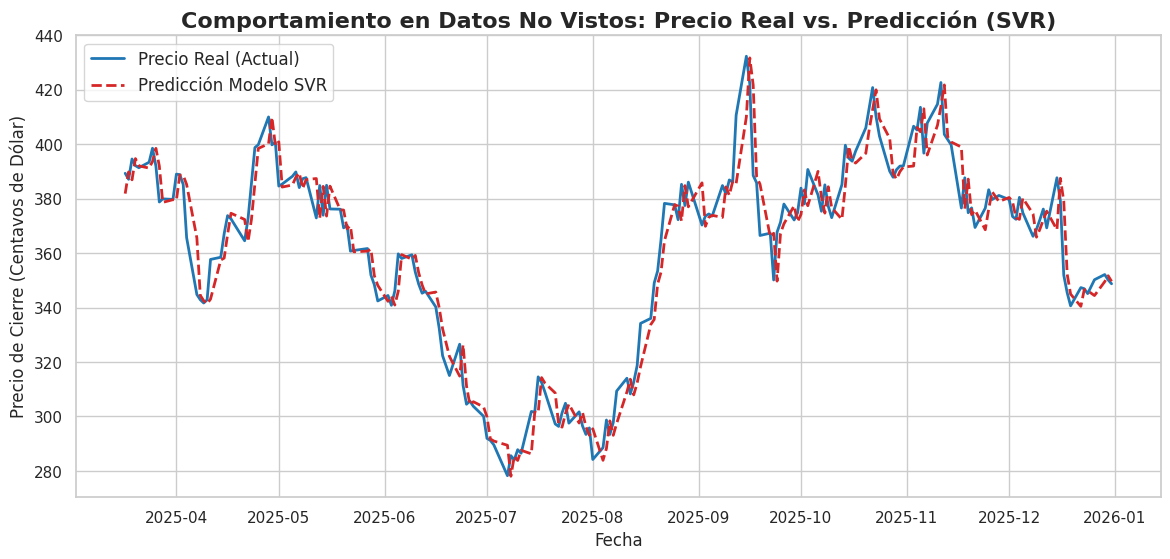

/tmp/ipykernel_9877/2184508934.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia (%)', y='Variable', data=df_importancias, palette='viridis')


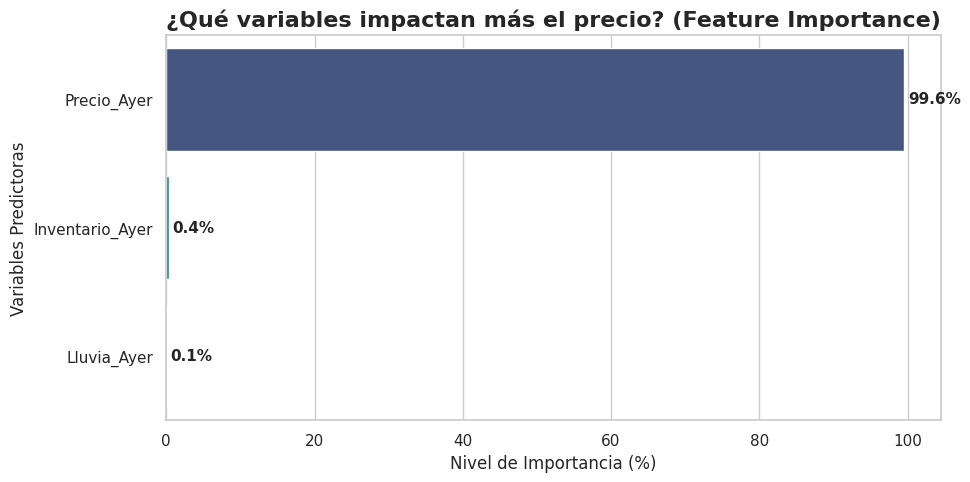

In [ ]:

sns.set_theme(style="whitegrid")

# ==============================================================================
# GRÁFICO DE PREDICCIÓN VS REALIDAD (Usando el SVR ganador)
# ==============================================================================

modelo_ganador = mejores_modelos['SVR']
y_pred_ganador = modelo_ganador.predict(X_test)

fechas_test = df_final.loc[y_test.index, 'Fecha']

plt.figure(figsize=(14, 6))

plt.plot(fechas_test, y_test, label='Precio Real (Actual)', color='#1f77b4', linewidth=2)

plt.plot(fechas_test, y_pred_ganador, label='Predicción Modelo SVR', color='#d62728', linestyle='--', linewidth=2)

plt.title('Comportamiento en Datos No Vistos: Precio Real vs. Predicción (SVR)', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio de Cierre (Centavos de Dólar)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.show()

# ==============================================================================
# GRÁFICO DE IMPORTANCIA DE VARIABLES (Usando Gradient Boosting)
# ==============================================================================

modelo_arboles = mejores_modelos['Gradient Boosting']
importancias = modelo_arboles.feature_importances_

df_importancias = pd.DataFrame({
    'Variable': columnas_features,
    'Importancia (%)': importancias * 100
}).sort_values(by='Importancia (%)', ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(x='Importancia (%)', y='Variable', data=df_importancias, palette='viridis')

plt.title('¿Qué variables impactan más el precio? (Feature Importance)', fontsize=16, fontweight='bold')
plt.xlabel('Nivel de Importancia (%)', fontsize=12)
plt.ylabel('Variables Predictoras', fontsize=12)


for index, value in enumerate(df_importancias['Importancia (%)']):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.show()

**Aplicación:**

Usuario Final: El modelo está diseñado para ser utilizado por la dirección de abastecimiento de la compañía procafecol Juan Valdez integrándola con el modelo de gestión de riesgo financiero

Decisiones que apoyara: La herramienta actuara complementaria para tomar una decisión de compra en futuros de café arábica y apoyara la decisión de fijar hoy o posponer la decisión unos días o semanas

Impacto: La compra de la materia prima puede representar saludablemente entre un 40% o 50% del EDITDA total de la compañía, fuera de esos rangos puede ser un riesgo financiero crítico, pero mantenerse en rangos de 40% o por debajo puede ser una ventaja competitiva al tener un modelo que explique el 93,6% de la varianza del precio, y se puede llegar a traducir en ahorros muy importantes.

Limitaciones: A pesar de que tiene una muy buena precisión estadística, este modelo no contempla otros factores como movimiento de la moneda de cada país y en especial el dólar vs Real brasileño, si el dólar se debilita el caficultor brasileño así tenga café no lo vende, otro factor importante son los eventos geopolíticos que puedan afectar el precio como por ejemplo guerras o crisis de abastecimiento mundiales.



**Conclusiones:**

1. Los resultados del modelo son muy buenos, tener un asertividad de que el precio se va a comportar un 93,6% como predice el modelo es increíble, y que en máximo error va a estar sobre los 33 cusd/lb, también es un buen indicio. Se tiene el modelo SVR idóneo para este entorno corporativo.

2. Este modelo tiene un rezago de 1 día y así es altamente preciso, sin embargo, es importante contextualizar que los mercados se compartan por un sentimiento estructural, por ejemplo, si la cosecha de 2027 de Brasil va a estar baja por las aparentes pocas lluvias pronosticadas.

3. Se debe trascender para la continuación del modelo hacia las variables acumulativas, por ejemplo, si a este modelo le sumamos ahora otra variable que es la temperatura y se cruzan con las variables acumuladas de 30 días de precipitaciones, se pueden crear alertas que permita cuantificar el sentir del mercado ante amenazas de sequias o heladas, dándole al modelo un nivel de predicción a lo largo del tiempo.

4. En el mercado el mejor predictor del precio hoy casi siembre es el precio de ayer, en este caso el precio esta dominando la predicción sin darle mucho valor al clima o inventarios efecto autorregresivo. Sin embargo, el 0,5% del impacto predictor que tiene el clima, la podemos interpretar como la señal oculta para predecir los cambios de tendencia



